# 03 — Is the spider code a quantum error-correcting code? The Knill–Laflamme test

**Where we are in the story.** The spider code is a bona fide order-$K$ rotation code (Notebook 02), so its
Fock-grid spacing guarantees that up to $K-1$ photon losses can be *detected*. Detection is not correction.
A code corrects an error set $\{\hat E_a\}$ if and only if the Knill–Laflamme (KL) conditions hold:

$$\langle i_L|\hat E_a^\dagger\hat E_b|j_L\rangle = C_{ab}\,\delta_{ij}\qquad\forall\,a,b,i,j .$$

Two things are being asked. **Orthogonality** ($i\ne j$): no error maps one codeword onto the other.
**Non-deformation** ($i=j$): both codewords see the *same* error statistics, so that the recovery does not
learn — and hence destroy — the logical information. For a rotation code and loss errors $\hat a^l$ ($l<K$)
orthogonality is automatic. Non-deformation for a single loss is simply

$$\langle 0_L|\hat n|0_L\rangle = \langle 1_L|\hat n|1_L\rangle ,$$

i.e. **the two codewords must have the same mean photon number.** We saw in Notebook 02 that for the spider
code they differ by a factor of three.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from spiderqec import precession as pr, rotation_codes as rc, knill_laflamme as kl, plotting as pl
pl.use_style()
%matplotlib inline
K, N = 3, 600

## Step 1 — the KL table for the spider code

Error set: identity, one and two photon losses ($K-1=2$ is the number of losses an order-3 code can detect),
and the leading dephasing error $\hat n$.

In [2]:
spider = pr.spider_state(K, N)
zero, one = rc.codewords_from_plus(spider.psi, K)
errors = kl.loss_errors(N, K - 1)
errors.update(kl.dephasing_errors(N, 1))

def show(name, z, o):
    v = kl.kl_violation([z, o], errors)
    print(f"--- {name}:  max orthogonality violation = {v['orthogonality']:.1e},  max deformation = {v['deformation']:.3g}")
    print(f"{'E_a^dag E_b':>12} | {'<0|.|0>':>10} | {'<1|.|1>':>10} | {'|<0|.|1>|':>9} | {'deformation':>11}")
    for r in v['table']:
        if r['pair'] in ('I†I', 'I†a', 'a†a', 'I†a^2', 'a†a^2', 'a^2†a^2', 'n†n'):
            print(f"{r['pair']:>12} | {r['c00']:10.3f} | {r['c11']:10.3f} | {r['off']:9.1e} | {r['deform']:11.3g}")
    return v

v_spider = show("SPIDER code, K=3", zero, one)

--- SPIDER code, K=3:  max orthogonality violation = 0.0e+00,  max deformation = 262
 E_a^dag E_b |    <0|.|0> |    <1|.|1> | |<0|.|1>| | deformation
         I†I |      1.000 |      1.000 |   0.0e+00 |    5.55e-16
         I†a |      0.000 |      0.000 |   0.0e+00 |           0
       I†a^2 |      0.000 |      0.000 |   0.0e+00 |           0
         a†a |      8.014 |     23.764 |   0.0e+00 |        15.8
       a†a^2 |      0.000 |      0.000 |   0.0e+00 |           0
     a^2†a^2 |   3253.003 |   3499.602 |   0.0e+00 |         247
         n†n |   3261.017 |   3523.366 |   0.0e+00 |         262


Orthogonality holds to machine precision — the Fock-grid spacing works as advertised. Non-deformation
fails already for a single loss ($\hat a^\dagger\hat a$ row): the two codewords have mean photon numbers
8 and 24. After a loss, the recovery could tell $|0_L\rangle$ from $|1_L\rangle$ by the *probability* of the loss
having happened, which is the same as saying the logical superposition is decohered. The code is
**detectable but not correctable**.

## Step 2 — the same table for codes that do work

Binomial codes satisfy KL exactly for a finite error set by construction; cat codes satisfy it asymptotically
(exponentially in $|\alpha|^2$).

In [3]:
for L in (2, 4):
    z, o = rc.codewords_from_plus(rc.binomial_plus(K, L, N), K)
    show(f"binomial code, K=3, L={L}  (nbar={rc.code_mean_photon(z,o):.1f})", z, o)
for al in (2.0, 3.0):
    z, o = rc.codewords_from_plus(rc.cat_plus(K, al, N), K)
    show(f"cat code, K=3, alpha={al}  (nbar={rc.code_mean_photon(z,o):.1f})", z, o)

--- binomial code, K=3, L=2  (nbar=3.0):  max orthogonality violation = 0.0e+00,  max deformation = 9
 E_a^dag E_b |    <0|.|0> |    <1|.|1> | |<0|.|1>| | deformation
         I†I |      1.000 |      1.000 |   0.0e+00 |    2.22e-16
         I†a |      0.000 |      0.000 |   0.0e+00 |           0
       I†a^2 |      0.000 |      0.000 |   0.0e+00 |           0
         a†a |      3.000 |      3.000 |   0.0e+00 |    8.88e-16
       a†a^2 |      0.000 |      0.000 |   0.0e+00 |           0
     a^2†a^2 |     15.000 |      6.000 |   0.0e+00 |           9
         n†n |     18.000 |      9.000 |   0.0e+00 |           9
--- binomial code, K=3, L=4  (nbar=6.0):  max orthogonality violation = 0.0e+00,  max deformation = 7.11e-15
 E_a^dag E_b |    <0|.|0> |    <1|.|1> | |<0|.|1>| | deformation
         I†I |      1.000 |      1.000 |   0.0e+00 |    1.11e-16
         I†a |      0.000 |      0.000 |   0.0e+00 |           0
       I†a^2 |      0.000 |      0.000 |   0.0e+00 |           0
         

The binomial code with $L=4$ satisfies every condition exactly (it corrects two losses *and* one dephasing
error); the cat code's deformation decays as $e^{-2|\alpha|^2}$-type corrections. The spider code's deformation,
by contrast, is of order $\bar n$ itself — and $\bar n$ diverges with the truncation.

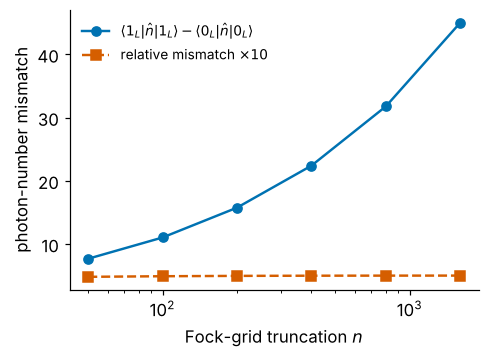

relative mismatch (n1-n0)/(n1+n0): [0.481 0.49  0.496 0.498 0.5   0.5  ]


In [4]:
grid = np.array([50, 100, 200, 400, 800, 1600])
mis = []
for n_grid in grid:
    st = pr.spider_state(K, K*n_grid)
    z, o = rc.codewords_from_plus(st.psi, K)
    mis.append((rc.mean_photon(z), rc.mean_photon(o)))
mis = np.array(mis)
fig, ax = plt.subplots(figsize=(4.8, 3.3))
ax.plot(grid, mis[:, 1] - mis[:, 0], "o-", label=r"$\langle 1_L|\hat n|1_L\rangle-\langle 0_L|\hat n|0_L\rangle$")
ax.plot(grid, (mis[:, 1] - mis[:, 0]) / (mis[:, 1] + mis[:, 0]) * 10, "s--", label=r"relative mismatch $\times 10$")
ax.set_xscale("log"); ax.set_xlabel("Fock-grid truncation $n$"); ax.set_ylabel("photon-number mismatch"); ax.legend()
pl.savefig(fig, "spider_kl_deformation_vs_truncation", subdir="03_knill_laflamme")
plt.show()
print("relative mismatch (n1-n0)/(n1+n0):", ((mis[:,1]-mis[:,0])/(mis[:,1]+mis[:,0])).round(3))

The relative mismatch locks at $\approx 0.50$: no truncation, however large, repairs it. This is a property
of the exact spider state, not of our numerics.

## Step 3 — can the spider code be repaired by "renormalising" the coefficients?

The legacy manuscript asked whether a naive rescaling of the Fock-grid coefficients could restore
non-deformation. Let us try the simplest one-parameter deformation, $|1_L\rangle\to\mathcal N\,(\hat n+1)^{-p/2}|1_L\rangle$,
which pulls the energy of $|1_L\rangle$ down towards that of $|0_L\rangle$, and watch what happens to (a) the KL
deformation for one and two losses and (b) the precession score of the resulting $|+_L\rangle$ — the property
that *defined* the spider in the first place.

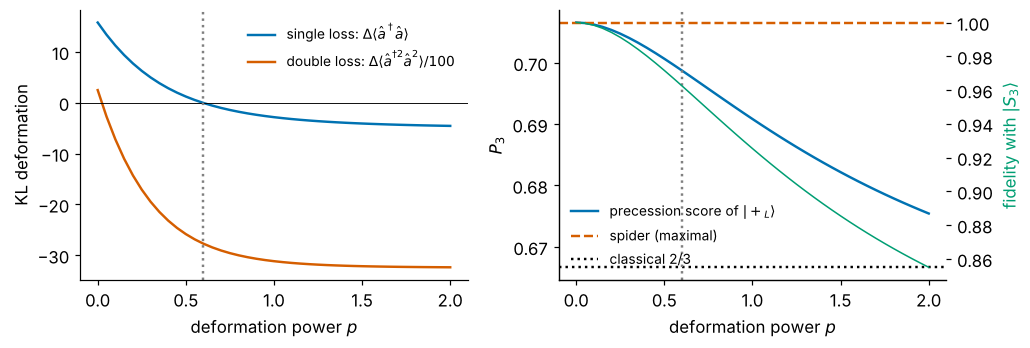

single-loss deformation vanishes at p = 0.60: there the double-loss deformation is -2773.2,
the score of |+_L> is 0.6987 (spider: 0.7066) and its fidelity with the spider state is 0.962.


In [5]:
ps = np.linspace(0, 2, 41)
res = []
for p in ps:
    o2 = kl.equalise_mean_photon(zero, one, p)
    plus2 = (zero + o2) / np.sqrt(2)
    v = kl.kl_violation([zero, o2], {"a": errors["a"], "a^2": errors["a^2"]})
    d1 = v["M"][0, 0, 1, 1].real - v["M"][0, 0, 0, 0].real      # <1|a†a|1> - <0|a†a|0>
    d2 = v["M"][1, 1, 1, 1].real - v["M"][1, 1, 0, 0].real      # <1|a†²a²|1> - <0|a†²a²|0>
    res.append((p, d1, d2, pr.score_of_state(plus2, K), np.dot(plus2, spider.psi) ** 2))
res = np.array(res)
p_star = ps[np.argmin(np.abs(res[:, 1]))]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.3))
ax = axes[0]
ax.plot(ps, res[:, 1], label=r"single loss: $\Delta\langle\hat a^\dagger\hat a\rangle$")
ax.plot(ps, res[:, 2] / 100, label=r"double loss: $\Delta\langle\hat a^{\dagger 2}\hat a^2\rangle/100$")
ax.axhline(0, color="k", lw=0.6); ax.axvline(p_star, color="0.5", ls=":")
ax.set_xlabel("deformation power $p$"); ax.set_ylabel("KL deformation"); ax.legend()
ax = axes[1]
ax.plot(ps, res[:, 3], label=r"precession score of $|+_L\rangle$")
ax.axhline(spider.score, color="C1", ls="--", label="spider (maximal)")
ax.axhline(pr.classical_bound(K), color="k", ls=":", label="classical 2/3")
ax.axvline(p_star, color="0.5", ls=":")
ax2 = ax.twinx(); ax2.plot(ps, res[:, 4], color="C2", lw=1); ax2.set_ylabel(r"fidelity with $|S_3\rangle$", color="C2")
ax.set_xlabel("deformation power $p$"); ax.set_ylabel("$P_3$"); ax.legend(loc="lower left")
fig.tight_layout()
pl.savefig(fig, "spider_kl_repair_tradeoff", subdir="03_knill_laflamme")
plt.show()
i = np.argmin(np.abs(res[:, 1]))
print(f"single-loss deformation vanishes at p = {p_star:.2f}: there the double-loss deformation is {res[i,2]:.1f},")
print(f"the score of |+_L> is {res[i,3]:.4f} (spider: {spider.score:.4f}) and its fidelity with the spider state is {res[i,4]:.3f}.")

Three lessons:

1. One free parameter fixes one KL condition. At $p\approx0.6$ the single-loss deformation vanishes, but the
   double-loss deformation is then in the thousands (it even changes sign); every further error demands another parameter, and the
   family converges to a binomial-like coefficient set, not to the spider.
2. The repaired state is **no longer the spider state**: its precession score drops below the maximum. It still
   violates the classical bound (that is robust), but the *certificate* of Notebook 02 — which relies on being the
   top eigenvector of $\hat Q_K$ — is lost.
3. The infinite energy is untouched by any reweighting of finitely many coefficients.

**Verdict.** Maximal violation of the precession bound and the KL non-deformation condition are incompatible
demands on the same set of Fock-grid coefficients. The spider state is an excellent *witness of quantumness* and a
valid *error-detecting* rotation code, but it is not an error-*correcting* code.

**Take-away for the story.** If the exotic primitive does not help, the limiting factor of rotation-code QEC
is not the choice of primitive but the *gadgets*: every rotation code needs the same two ingredients for
teleportation-based error correction, a CROT gate $e^{i\varphi\hat n\otimes\hat n}$ and a phase measurement.
Notebook 04 turns to the hardware for the CROT gate.